In [ ]:
import numpy as np
import pandas as pd
from scipy.io import arff
import urllib.request
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1.DATA LOADING
# These functions load CSV or ARFF files and show basic information.

def load_csv(path):
    df = pd.read_csv(path)
    print("\nDataset Overview (CSV)")
    print("File:", path)
    print("Shape:", df.shape) # number of rows and columns
    print(df.head())          # show first 5 rows
    print("\nMissing values:\n", df.isnull().sum())
    return df

def load_arff(path):
      # Load ARFF from Kaggle local path
          with open(path, "r", encoding="utf-8", errors="ignore") as f:
                  text = f.read()

          data, meta = arff.loadarff(StringIO(text))
          df = pd.DataFrame(data)

                              # Convert b'YES' → 'YES'
          for col in df.columns:
                  if df[col].dtype == object:
                     df[col] = df[col].apply(
                        lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
                                                                                  )

          print("\nDataset Overview (ARFF)")
          print("File:", path)
          print("Shape:", df.shape)
          print(df.head())
          print("\nMissing values:\n", df.isnull().sum())
          return df

def load_dataset(path):
      # Auto-detect CSV vs ARFF
       if path.lower().endswith(".csv"):
              return load_csv(path)
       else:
              return load_arff(path)

# Kaggle dataset paths

url_toddler = '/content/drive/MyDrive/Toddler Autism dataset July 2018.csv'

# Folder containing the ARFF datasets
#base_path = '/kaggle/input/autism-spectrum-disorder-arff-files/ASD_datasets'

url_child      = '/content/drive/MyDrive/Autism-Child-Data.arff'
url_adolescent = '/content/drive/MyDrive/Autism-Adolescent-Data.arff'
url_adult      = '/content/drive/MyDrive/Autism-Adult-Data.arff'


# ------------------------------
# Load all datasets
# ------------------------------
df_toddler    = load_dataset(url_toddler)
df_child      = load_dataset(url_child)
df_adolescent = load_dataset(url_adolescent)
df_adult      = load_dataset(url_adult)


Dataset Overview (CSV)
File: /content/drive/MyDrive/Toddler Autism dataset July 2018.csv
Shape: (1054, 19)
   Case_No  A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age_Mons  Qchat-10-Score  \
0        1   0   0   0   0   0   0   1   1   0    1        28               3   
1        2   1   1   0   0   0   1   1   0   0    0        36               4   
2        3   1   0   0   0   0   0   1   1   0    1        36               4   
3        4   1   1   1   1   1   1   1   1   1    1        24              10   
4        5   1   1   0   1   1   1   1   1   1    1        20               9   

  Sex       Ethnicity Jaundice Family_mem_with_ASD Who completed the test  \
0   f  middle eastern      yes                  no          family member   
1   m  White European      yes                  no          family member   
2   m  middle eastern      yes                  no          family member   
3   m        Hispanic       no                  no          family member   
4   f  White Europea

In [ ]:
# 2. Show missing values for each dataset

def show_missing(df, name):
    print(f"\nMissing values in {name} dataset:")
    print(df.isnull().sum())

show_missing(df_toddler,    "Toddler")
show_missing(df_child,      "Child")
show_missing(df_adolescent, "Adolescent")
show_missing(df_adult,      "Adult")


Missing values in Toddler dataset:
Case_No                   0
A1                        0
A2                        0
A3                        0
A4                        0
A5                        0
A6                        0
A7                        0
A8                        0
A9                        0
A10                       0
Age_Mons                  0
Qchat-10-Score            0
Sex                       0
Ethnicity                 0
Jaundice                  0
Family_mem_with_ASD       0
Who completed the test    0
Class/ASD Traits          0
dtype: int64

Missing values in Child dataset:
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                4
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_des

In [ ]:
# 3. Preprocessing functions

def encode_target(y):
# Convert ASD labels like 'YES', 'Yes', '1' into 1, and 'NO', 'No', '0' into 0.

     y = y.astype(str).str.lower().str.strip()
     mapping = {"yes": 1, "1": 1, "no": 0, "0": 0, "true": 1, "false": 0}
     return y.map(mapping)

def preprocess(df, target_col, drop_cols=None):
      print("\nPreprocessing Overview")
       # Remove rows with "?"
      df = df.replace("?", pd.NA)
      df = df.dropna().reset_index(drop=True)

      # Remove useless columns such as ID numbers
      if drop_cols:
          df = df.drop(columns=drop_cols, errors="ignore")

      print("Columns after dropping:", df.columns.tolist())

      # Make sure target column has no missing values
      df = df.dropna(subset=[target_col])

      # Fill missing values in other columns with the most common value
      for col in df.columns:
          if col == target_col:
                continue
          if df[col].isnull().sum() > 0:
               df[col] = df[col].fillna(df[col].mode()[0])

      print("\nMissing values after cleaning:\n", df.isnull().sum())

      # Convert labels (Yes/No) → 1/0
      y = encode_target(df[target_col])

      # Remove the target column from features
      X = df.drop(columns=[target_col])

      # Convert text columns into numbers (Label Encoding)
      X_encoded = X.copy()
      for col in X_encoded.columns:
                 if X_encoded[col].dtype == object:
                           le = LabelEncoder()
                           X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

      print("Final feature count:", X_encoded.shape[1])
      print("Sample encoded rows:\n", X_encoded.head())

      return X_encoded, y

# Apply preprocessing to each dataset

# Toddler: target is "Class/ASD Traits " and we drop Case_No
Xt, yt = preprocess(
         df_toddler,
         target_col="Class/ASD Traits ",
         drop_cols=["Case_No"]
)

# Child / Adolescent / Adult: target is "Class/ASD"
Xc, yc   = preprocess(df_child,      target_col="Class/ASD")
Xa, ya   = preprocess(df_adolescent, target_col="Class/ASD")
Xad, yad = preprocess(df_adult,      target_col="Class/ASD")




Preprocessing Overview
Columns after dropping: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']

Missing values after cleaning:
 A1                        0
A2                        0
A3                        0
A4                        0
A5                        0
A6                        0
A7                        0
A8                        0
A9                        0
A10                       0
Age_Mons                  0
Qchat-10-Score            0
Sex                       0
Ethnicity                 0
Jaundice                  0
Family_mem_with_ASD       0
Who completed the test    0
Class/ASD Traits          0
dtype: int64
Final feature count: 17
Sample encoded rows:
    A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age_Mons  Qchat-10-Score  Sex  \
0   0   0   0   0   0   0   1   1   0    1        28               3    0   
1   1   

Feature correlation with ASD (Toddler):
ASD                       1.000000
Qchat-10-Score            0.810423
A9                        0.577336
A6                        0.569424
A5                        0.563297
A7                        0.563177
A4                        0.505204
A1                        0.503810
A2                        0.463467
A8                        0.427155
A3                        0.409701
A10                       0.179833
Sex                       0.117664
Jaundice                  0.074060
Age_Mons                  0.066831
Who completed the test   -0.010993
Family_mem_with_ASD      -0.013503
Ethnicity                -0.146357
Name: ASD, dtype: float64


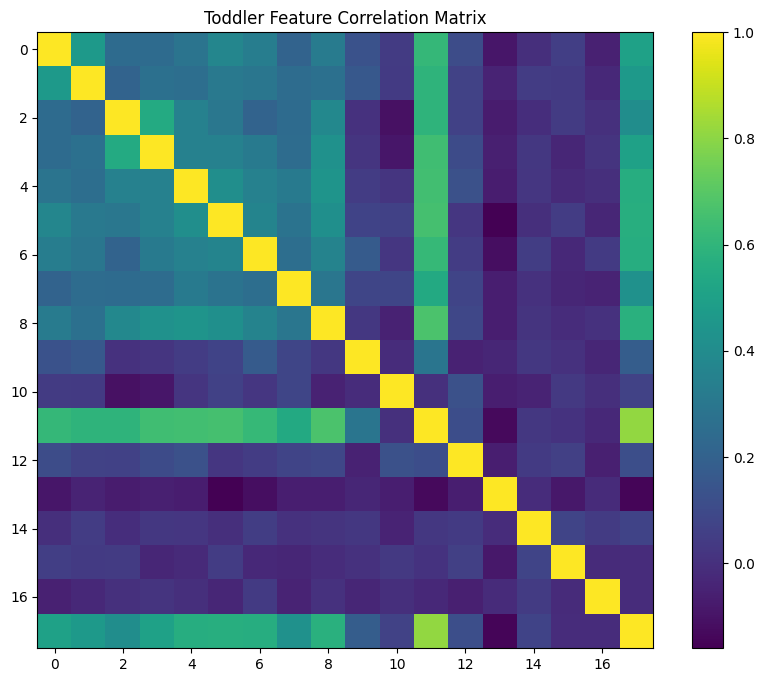

In [ ]:
# -----------------------------
# 4. Feature Correlation Analysis
# -----------------------------

import matplotlib.pyplot as plt

# Example: Toddler dataset correlation with target
corr_toddler = Xt.copy()
corr_toddler["ASD"] = yt

# Correlation of each feature with target
print("Feature correlation with ASD (Toddler):")
print(corr_toddler.corr(numeric_only=True)["ASD"].sort_values(ascending=False))

# Full correlation matrix visualization
plt.figure(figsize=(10,8))
plt.imshow(corr_toddler.corr(numeric_only=True))
plt.colorbar()
plt.title("Toddler Feature Correlation Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -----------------------------------
# Split with ALL features
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    Xt, yt, test_size=0.2, random_state=42
)

# Remove weak-correlation features
weak_features = [
    "Who completed the test",
    "Family_mem_with_ASD",
    "Ethnicity"
]

Xt_reduced = Xt.drop(columns=weak_features)

# Split with reduced features
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    Xt_reduced, yt, test_size=0.2, random_state=42
)

# -----------------------------------
# Compare all models
# -----------------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("Feature Removal Comparison:\n")

for name, model in models.items():

    # Train with all features
    model.fit(X_train, y_train)
    pred1 = model.predict(X_test)
    acc_all = accuracy_score(y_test, pred1)

    # Train without weak features
    model.fit(X_train2, y_train2)
    pred2 = model.predict(X_test2)
    acc_reduced = accuracy_score(y_test2, pred2)

    print(f"{name}")
    print(f" Accuracy with all features: {acc_all:.4f}")
    print(f" Accuracy after removing weak features: {acc_reduced:.4f}")

    if acc_reduced <= acc_all:
        print(" Conclusion: Keep the features")
    else:
        print(" Conclusion: Consider removing them")

    print("-"*50)

Feature Removal Comparison:

Logistic Regression
 Accuracy with all features: 1.0000
 Accuracy after removing weak features: 1.0000
 Conclusion: Keep the features
--------------------------------------------------
Naive Bayes
 Accuracy with all features: 0.9716
 Accuracy after removing weak features: 0.9668
 Conclusion: Keep the features
--------------------------------------------------
KNN
 Accuracy with all features: 0.9810
 Accuracy after removing weak features: 0.9810
 Conclusion: Keep the features
--------------------------------------------------
SVM (RBF)
 Accuracy with all features: 1.0000
 Accuracy after removing weak features: 1.0000
 Conclusion: Keep the features
--------------------------------------------------
Decision Tree
 Accuracy with all features: 1.0000
 Accuracy after removing weak features: 1.0000
 Conclusion: Keep the features
--------------------------------------------------
Random Forest
 Accuracy with all features: 1.0000
 Accuracy after removing weak featur

In [ ]:


# 4. Train/test split and scaling

def split_data(X, y):
     print("\nTrain/Test Split")

     # Split without shuffling to keep results stable
     X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.3, shuffle=False
     )

     print("Train size:", X_train.shape)
     print("Test size :", X_test.shape)

     # Standardize features (mean 0, std 1)
     scaler = StandardScaler()
     X_train_scaled = scaler.fit_transform(X_train)
     X_test_scaled = scaler.transform(X_test)

     return X_train_scaled, X_test_scaled, y_train, y_test

# Split all four datasets
Xt_tr,  Xt_te,  yt_tr,  yt_te  = split_data(Xt,  yt)
Xc_tr,  Xc_te,  yc_tr,  yc_te  = split_data(Xc,  yc)
Xa_tr,  Xa_te,  ya_tr,  ya_te  = split_data(Xa,  ya)
Xad_tr, Xad_te, yad_tr, yad_te = split_data(Xad, yad)


Train/Test Split
Train size: (737, 17)
Test size : (317, 17)

Train/Test Split
Train size: (173, 20)
Test size : (75, 20)

Train/Test Split
Train size: (68, 20)
Test size : (30, 20)

Train/Test Split
Train size: (426, 20)
Test size : (183, 20)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# find best k using training data (example: Toddler dataset)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(Xt_tr, yt_tr)

best_k = grid.best_params_['n_neighbors']
print("Best k found:", best_k)

Best k found: 5


In [ ]:
# 5. Define all models we will use

def get_models():
    return {
             "Logistic Regression": LogisticRegression(max_iter=2000),
             "Naive Bayes": GaussianNB(),
             "KNN": KNeighborsClassifier(n_neighbors=best_k),
             "SVM (RBF)": SVC(kernel="rbf", probability=True),
             "Decision Tree": DecisionTreeClassifier(random_state=42),
             "Random Forest": RandomForestClassifier(random_state=42),
           }

models = get_models()
models

{'Logistic Regression': LogisticRegression(max_iter=2000),
 'Naive Bayes': GaussianNB(),
 'KNN': KNeighborsClassifier(),
 'SVM (RBF)': SVC(probability=True),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42)}

In [ ]:
# 6. Training and evaluation

results_table = []
def evaluate(models, X_train, X_test, y_train, y_test, dataset_name):
    print("\n" + "=" * 70)
    print(f"RESULTS FOR DATASET: {dataset_name}")
    print("=" * 70)

    for name, model in models.items():
            model.fit(X_train, y_train)     # train model
            preds = model.predict(X_test)   # make predictions

            # Calculate Metrics
            acc = accuracy_score(y_test, preds)
            prec = precision_score(y_test, preds, zero_division=0)
            rec = recall_score(y_test, preds, zero_division=0)
            f1 = f1_score(y_test, preds, zero_division=0)
            cm = confusion_matrix(y_test, preds)

            # show results
            print(f"\n----- {name} -----")
            print(f"Accuracy : {acc:.4f}")
            print(f"Precision: {prec:.4f}")
            print(f"Recall   : {rec:.4f}")
            print(f"F1-score : {f1:.4f}")
            print("Confusion Matrix:")
            print(f"[{cm[0][0]} {cm[0][1]}\n {cm[1][0]} {cm[1][1]}]")

            # save results for summary table
            results_table.append({
                     "Dataset": dataset_name,
                     "Model": name,
                     "Accuracy": acc,
                     "Precision": prec,
                     "Recall": rec,
                     "F1-score": f1,
                     "CM": cm
            })
# Evaluate models on each dataset
evaluate(models, Xt_tr,  Xt_te,  yt_tr,  yt_te,  "Toddler")
evaluate(models, Xc_tr,  Xc_te,  yc_tr,  yc_te,  "Child")
evaluate(models, Xa_tr,  Xa_te,  ya_tr,  ya_te,  "Adolescent")
evaluate(models, Xad_tr, Xad_te, yad_tr, yad_te, "Adult")



RESULTS FOR DATASET: Toddler

----- Logistic Regression -----
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
Confusion Matrix:
[95 0
 0 222]

----- Naive Bayes -----
Accuracy : 0.9621
Precision: 0.9688
Recall   : 0.9775
F1-score : 0.9731
Confusion Matrix:
[88 7
 5 217]

----- KNN -----
Accuracy : 0.9716
Precision: 0.9819
Recall   : 0.9775
F1-score : 0.9797
Confusion Matrix:
[91 4
 5 217]

----- SVM (RBF) -----
Accuracy : 0.9842
Precision: 0.9822
Recall   : 0.9955
F1-score : 0.9888
Confusion Matrix:
[91 4
 1 221]

----- Decision Tree -----
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
Confusion Matrix:
[95 0
 0 222]

----- Random Forest -----
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
Confusion Matrix:
[95 0
 0 222]

RESULTS FOR DATASET: Child

----- Logistic Regression -----
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
Confusion Matrix:
[41 0
 0 34]

----- Naive Bayes -----
Accur

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd
# Load the new autism dataset (age 2–17)
path_new = "/content/drive/MyDrive/1-Autismdata_age(2-17).xlsx"
df_new = pd.read_excel(path_new)

print("Shape:", df_new.shape)
df_new.head()

Shape: (200, 17)


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Class,First Diagnosis,Age,Gender
0,1,0,1,0,0,0,1,1,0,1,0,0,0,1,ADHD /Autism,14,Male
1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,Autism,11,Male
2,0,0,1,1,0,1,1,1,0,1,1,0,0,1,Mental deficiency /Autism,11,Female
3,1,1,0,0,0,1,1,1,1,1,1,1,0,1,Mental deficiency,18,Male
4,1,1,1,1,0,1,1,1,1,1,1,1,1,0,Mental deficiency,6,Female


In [ ]:
#exploring missing values
df_new.isnull().sum()

,0
Q1,0
Q2,0
Q3,0
Q4,0
Q5,0
Q6,0
Q7,0
Q8,0
Q9,0
Q10,0


In [ ]:
# Create binary ASD label based on diagnosis text
# First Diagnosis column- convert it into a 0–1 target

df_new["ASD_label"] = df_new["First  Diagnosis"].astype(str).str.contains(
    "autism", case=False, na=False
    ).astype(int)

df_new["ASD_label"].value_counts()

,count
ASD_label,
1,129
0,71


In [ ]:
# Preprocessing
# Drop columns that are not predictors:“Class” & “First Diagnosis”

drop_cols_new = ["Class", "First  Diagnosis"]

X_new, y_new = preprocess(df_new, target_col="ASD_label", drop_cols=drop_cols_new)

X_new.head()


Preprocessing Overview
Columns after dropping: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Age', 'Gender', 'ASD_label']

Missing values after cleaning:
 Q1           0
Q2           0
Q3           0
Q4           0
Q5           0
Q6           0
Q7           0
Q8           0
Q9           0
Q10          0
Q11          0
Q12          0
Q13          0
Age          0
Gender       0
ASD_label    0
dtype: int64
Final feature count: 15
Sample encoded rows:
    Q1  Q2  Q3  Q4  Q5  Q6  Q7  Q8  Q9  Q10  Q11  Q12  Q13  Age  Gender
0   1   0   1   0   0   0   1   1   0    1    0    0    0   14       1
1   0   0   0   0   0   0   0   1   0    0    0    0    0   11       1
2   0   0   1   1   0   1   1   1   0    1    1    0    0   11       0
3   1   1   0   0   0   1   1   1   1    1    1    1    0   18       1
4   1   1   1   1   0   1   1   1   1    1    1    1    1    6       0


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Age,Gender
0,1,0,1,0,0,0,1,1,0,1,0,0,0,14,1
1,0,0,0,0,0,0,0,1,0,0,0,0,0,11,1
2,0,0,1,1,0,1,1,1,0,1,1,0,0,11,0
3,1,1,0,0,0,1,1,1,1,1,1,1,0,18,1
4,1,1,1,1,0,1,1,1,1,1,1,1,1,6,0


In [ ]:
# Train/ split
Xn_train, Xn_test, yn_train, yn_test = split_data(X_new, y_new)

Xn_train.shape, Xn_test.shape


Train/Test Split
Train size: (140, 15)
Test size : (60, 15)


((140, 15), (60, 15))

In [ ]:
# Train and Evaluate Models

models = get_models()
evaluate(models, Xn_train, Xn_test, yn_train, yn_test, dataset_name="New ASD Dataset")


RESULTS FOR DATASET: New ASD Dataset

----- Logistic Regression -----
Accuracy : 0.8000
Precision: 0.9268
Recall   : 0.8085
F1-score : 0.8636
Confusion Matrix:
[10 3
 9 38]

----- Naive Bayes -----
Accuracy : 0.8333
Precision: 1.0000
Recall   : 0.7872
F1-score : 0.8810
Confusion Matrix:
[13 0
 10 37]

----- KNN -----
Accuracy : 0.9333
Precision: 1.0000
Recall   : 0.9149
F1-score : 0.9556
Confusion Matrix:
[13 0
 4 43]

----- SVM (RBF) -----
Accuracy : 0.8333
Precision: 0.9744
Recall   : 0.8085
F1-score : 0.8837
Confusion Matrix:
[12 1
 9 38]

----- Decision Tree -----
Accuracy : 0.7667
Precision: 0.9714
Recall   : 0.7234
F1-score : 0.8293
Confusion Matrix:
[12 1
 13 34]

----- Random Forest -----
Accuracy : 0.8333
Precision: 0.9744
Recall   : 0.8085
F1-score : 0.8837
Confusion Matrix:
[12 1
 9 38]


In [ ]:
# Build the full results DataFrame from the collected metrics
df_results = pd.DataFrame(results_table)

# Show 4 separate tables: one per dataset
datasets_order = ["Toddler", "Child", "Adolescent", "Adult"]

for ds_name in datasets_order:
    print("\n" + "#" * 60)
    print(f"Results for {ds_name} dataset")
    print("#" * 60)

    df_ds = df_results[df_results["Dataset"] == ds_name].copy()
    display(df_ds[["Model", "Accuracy", "Precision", "Recall", "F1-score"]])


############################################################
Results for Toddler dataset
############################################################


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Naive Bayes,0.962145,0.968750,0.977477,0.973094
2,KNN,0.971609,0.981900,0.977477,0.979684
3,SVM (RBF),0.984227,0.982222,0.995495,0.988814
4,Decision Tree,1.000000,1.000000,1.000000,1.000000
5,Random Forest,1.000000,1.000000,1.000000,1.000000



############################################################
Results for Child dataset
############################################################


,Model,Accuracy,Precision,Recall,F1-score
6,Logistic Regression,1.000000,1.000000,1.000000,1.000000
7,Naive Bayes,0.973333,1.000000,0.941176,0.969697
8,KNN,0.893333,0.809524,1.000000,0.894737
9,SVM (RBF),0.973333,0.970588,0.970588,0.970588
10,Decision Tree,1.000000,1.000000,1.000000,1.000000
11,Random Forest,1.000000,1.000000,1.000000,1.000000



############################################################
Results for Adolescent dataset
############################################################


,Model,Accuracy,Precision,Recall,F1-score
12,Logistic Regression,0.933333,0.882353,1.000000,0.937500
13,Naive Bayes,0.933333,0.933333,0.933333,0.933333
14,KNN,0.700000,0.625000,1.000000,0.769231
15,SVM (RBF),0.833333,0.750000,1.000000,0.857143
16,Decision Tree,1.000000,1.000000,1.000000,1.000000
17,Random Forest,1.000000,1.000000,1.000000,1.000000



############################################################
Results for Adult dataset
############################################################


,Model,Accuracy,Precision,Recall,F1-score
18,Logistic Regression,0.994536,0.984848,1.000000,0.992366
19,Naive Bayes,0.950820,0.888889,0.984615,0.934307
20,KNN,0.918033,0.867647,0.907692,0.887218
21,SVM (RBF),0.967213,0.968254,0.938462,0.953125
22,Decision Tree,1.000000,1.000000,1.000000,1.000000
23,Random Forest,1.000000,1.000000,1.000000,1.000000


In [ ]:
# results tables for 4 datasets
model_map = {
       "Decision Tree": "DT",
       "Logistic Regression": "LR",
       "SVM (RBF)": "SVM",
       "Naive Bayes": "NB",
       "KNN": "K-NN",
       "Random Forest": "RF"

}

datasets = ["Toddler", "Child", "Adolescent", "Adult"]

def format_cm(cm):
  return f"[{cm[0][0]} {cm[0][1]}\n {cm[1][0]} {cm[1][1]}]"

rows = []

for ds in datasets:
  subset = df_results[df_results.Dataset == ds]

  acc_row = {"Dataset": ds, "Metric": "Accuracy"}
  cm_row  = {"Dataset": ds, "Metric": "Confusion Matrix"}

  for model, short in model_map.items():
           acc = subset[subset.Model == model]["Accuracy"].values[0] * 100
           cm  = subset[subset.Model == model]["CM"].values[0]
           acc_row[short] = f"{acc:.1f}%"

           cm_row[short]  = format_cm(cm)

  rows.append(acc_row)
  rows.append(cm_row)

combined_table = pd.DataFrame(rows)
display(combined_table)

,Dataset,Metric,DT,LR,SVM,NB,K-NN,RF
0,Toddler,Accuracy,100.0%,100.0%,98.4%,96.2%,97.2%,100.0%
1,Toddler,Confusion Matrix,[95 0\n 0 222],[95 0\n 0 222],[91 4\n 1 221],[88 7\n 5 217],[91 4\n 5 217],[95 0\n 0 222]
2,Child,Accuracy,100.0%,100.0%,97.3%,97.3%,89.3%,100.0%
3,Child,Confusion Matrix,[41 0\n 0 34],[41 0\n 0 34],[40 1\n 1 33],[41 0\n 2 32],[33 8\n 0 34],[41 0\n 0 34]
4,Adolescent,Accuracy,100.0%,93.3%,83.3%,93.3%,70.0%,100.0%
5,Adolescent,Confusion Matrix,[15 0\n 0 15],[13 2\n 0 15],[10 5\n 0 15],[14 1\n 1 14],[6 9\n 0 15],[15 0\n 0 15]
6,Adult,Accuracy,100.0%,99.5%,96.7%,95.1%,91.8%,100.0%
7,Adult,Confusion Matrix,[118 0\n 0 65],[117 1\n 0 65],[116 2\n 4 61],[110 8\n 1 64],[109 9\n 6 59],[118 0\n 0 65]


In [ ]:
# Results table for the NEW ASD DATASET (Age 2–17)
results_new =[
      {"Dataset": "New ASD Dataset", "Model": "Logistic Regression",
           "Accuracy": 0.8000, "Precision": 0.9268, "Recall": 0.8085, "F1-score": 0.8636},
      {"Dataset": "New ASD Dataset", "Model": "Naive Bayes",
             "Accuracy": 0.8333, "Precision": 1.0000, "Recall": 0.7872, "F1-score": 0.8810},
       {"Dataset": "New ASD Dataset", "Model": "KNN",
            "Accuracy": 0.9333, "Precision": 1.0000, "Recall": 0.9149, "F1-score": 0.9556},
       {"Dataset": "New ASD Dataset", "Model": "SVM (RBF)",
            "Accuracy": 0.8333, "Precision": 0.9744, "Recall": 0.8085, "F1-score": 0.8837},
       {"Dataset": "New ASD Dataset", "Model": "Decision Tree",
            "Accuracy": 0.7667, "Precision": 0.9714, "Recall": 0.7234, "F1-score": 0.8293},
       {"Dataset": "New ASD Dataset", "Model": "Random Forest",
            "Accuracy": 0.8333, "Precision": 0.9744, "Recall": 0.8085, "F1-score": 0.8837},


]
# Convert to DataFrame
df_new_asd = pd.DataFrame(results_new)

# Display table formatted exactly like your Kaggle style
print("\n" + "#" * 60)
print("Results for NEW ASD DATASET (Age 2–17)")
print("#" * 60)

display(df_new_asd[["Model", "Accuracy", "Precision", "Recall", "F1-score"]])



############################################################
Results for NEW ASD DATASET (Age 2–17)
############################################################


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8000,0.9268,0.8085,0.8636
1,Naive Bayes,0.8333,1.0000,0.7872,0.8810
2,KNN,0.9333,1.0000,0.9149,0.9556
3,SVM (RBF),0.8333,0.9744,0.8085,0.8837
4,Decision Tree,0.7667,0.9714,0.7234,0.8293
5,Random Forest,0.8333,0.9744,0.8085,0.8837


Accuracy table for all datasets:


,Dataset,DT,LR,SVM,NB,K-NN,RF
0,Toddler,100.00,100.000000,98.422713,96.214511,97.160883,100.00
1,Child,100.00,100.000000,97.333333,97.333333,89.333333,100.00
2,Adolescent,100.00,93.333333,83.333333,93.333333,70.000000,100.00
3,Adult,100.00,99.453552,96.721311,95.081967,91.803279,100.00
4,New ASD Dataset,76.67,80.000000,83.330000,83.330000,93.330000,83.33


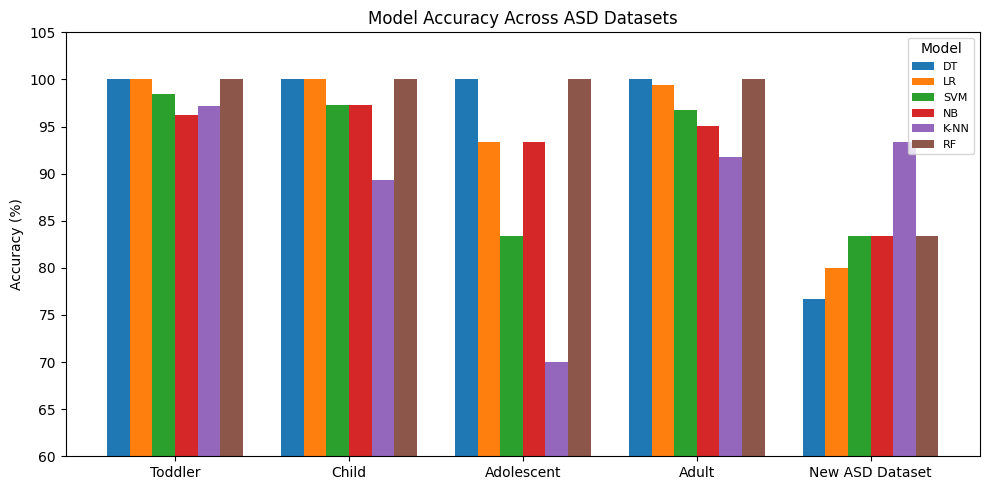

In [ ]:
#Bar chart for all datasets

# Map full model names to short labels
model_map = {
      "Decision Tree": "DT",
      "Logistic Regression": "LR",
      "SVM (RBF)": "SVM",
      "Naive Bayes": "NB",
       "KNN": "K-NN",
       "Random Forest": "RF"
}

# Order of datasets on the x-axis
datasets_all = ["Toddler", "Child", "Adolescent", "Adult", "New ASD Dataset"]
rows = []

for ds in datasets_all:
      if ds == "New ASD Dataset":
           subset = df_new_asd  # this holds only the new dataset res
      else:
           subset = df_results[df_results["Dataset"] == ds]
      row = {"Dataset": ds}

      for full_name, short_name in model_map.items():
                # get accuracy (0–1) and convert to percentage
                 acc = subset[subset["Model"] == full_name]["Accuracy"].values[0] * 100.0
                 row[short_name] = acc

      rows.append(row)

# Build accuracy table: one row per dataset, columns = models
df_acc = pd.DataFrame(rows)

print("Accuracy table for all datasets:")
display(df_acc)

# Grouped bar chart
plt.figure(figsize=(10, 5))

x = np.arange(len(datasets_all))  # positions for datasets
models_short = ["DT", "LR", "SVM", "NB", "K-NN", "RF"]
width = 0.13  # bar width

for i, m in enumerate(models_short):
      plt.bar(x + i*width, df_acc[m], width=width, label=m)

plt.xticks(x + width*2.5, datasets_all, rotation=0)
plt.ylim(60, 105)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Across ASD Datasets")
plt.legend(title="Model", fontsize=8)
plt.tight_layout()
plt.show()